In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape


(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [12]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [14]:
numeric_df = df[
    ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [15]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


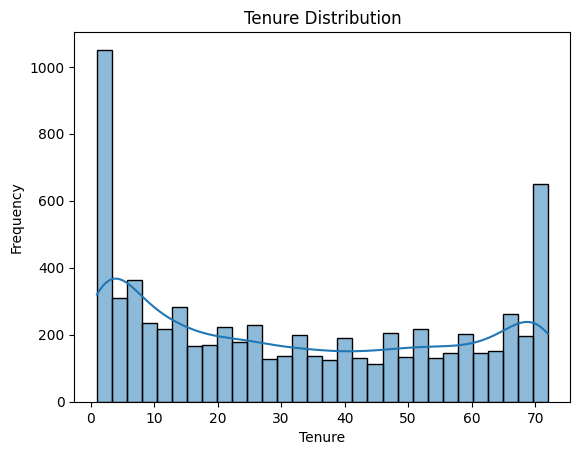

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['tenure'], kde=True, bins=30)

plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()

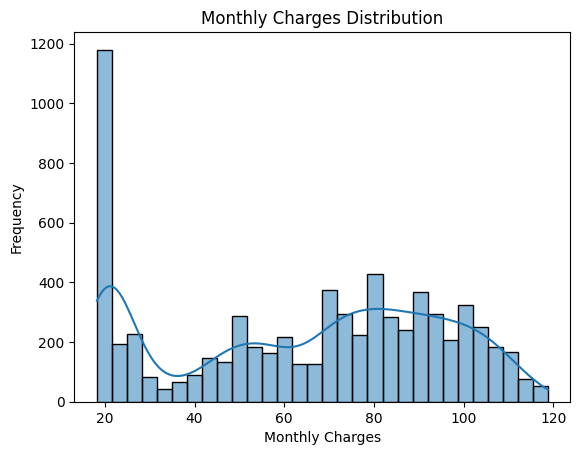

In [17]:
sns.histplot(df['MonthlyCharges'], kde=True, bins=30)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

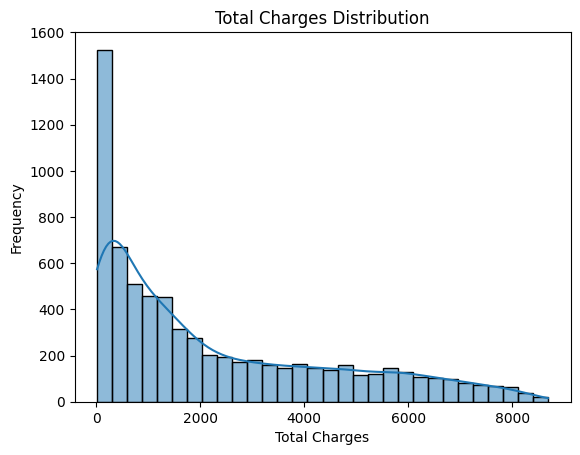

In [18]:
sns.histplot(df['TotalCharges'], kde=True, bins=30)

plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

In [19]:
for col in df.columns:
    print("=" * 50)
    print("Column:", col)
    print("Data Type:", df[col].dtype)
    print("Unique Values:", df[col].nunique())

    if df[col].dtype == 'object':
        print(df[col].value_counts())
    else:
        print(df[col].describe())

    print()

Column: customerID
Data Type: object
Unique Values: 7032
customerID
7590-VHVEG    1
0265-PSUAE    1
2956-GGUCQ    1
6008-NAIXK    1
5956-YHHRX    1
             ..
7874-ECPQJ    1
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64

Column: gender
Data Type: object
Unique Values: 2
gender
Male      3549
Female    3483
Name: count, dtype: int64

Column: SeniorCitizen
Data Type: int64
Unique Values: 2
count    7032.000000
mean        0.162400
std         0.368844
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

Column: Partner
Data Type: object
Unique Values: 2
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Column: Dependents
Data Type: object
Unique Values: 2
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

Column: tenure
Data Type: int64
Unique Values: 72
count    7032.000000
mean       32.421786
std        24.545260
m

In [20]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

for col in categorical_cols:
    print("=" * 40)
    print(col)
    print(df[col].value_counts())
    print()

Contract
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64



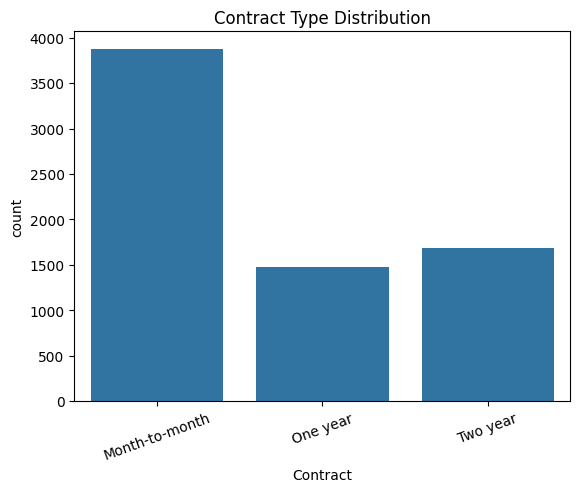

In [21]:
sns.countplot(data=df, x='Contract')
plt.title('Contract Type Distribution')
plt.xticks(rotation=20)
plt.show()

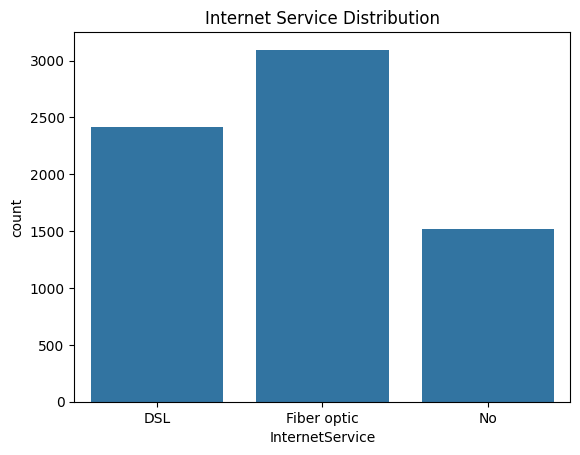

In [22]:
sns.countplot(data=df, x='InternetService')
plt.title('Internet Service Distribution')
plt.show()

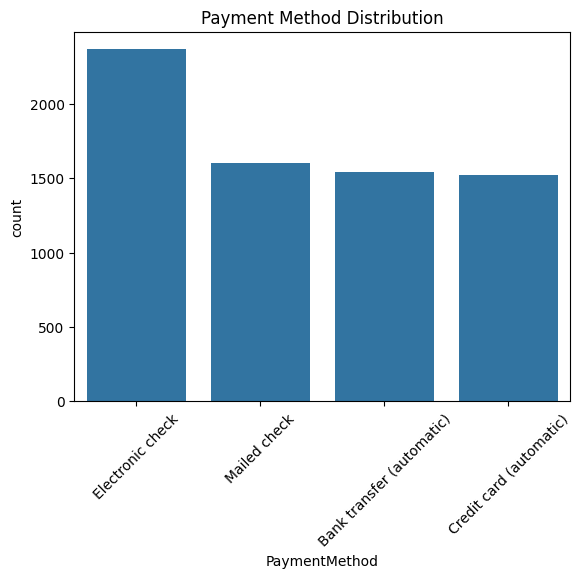

In [23]:
sns.countplot(data=df, x='PaymentMethod')
plt.title('Payment Method Distribution')
plt.xticks(rotation=45)
plt.show()


In [24]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [25]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [26]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


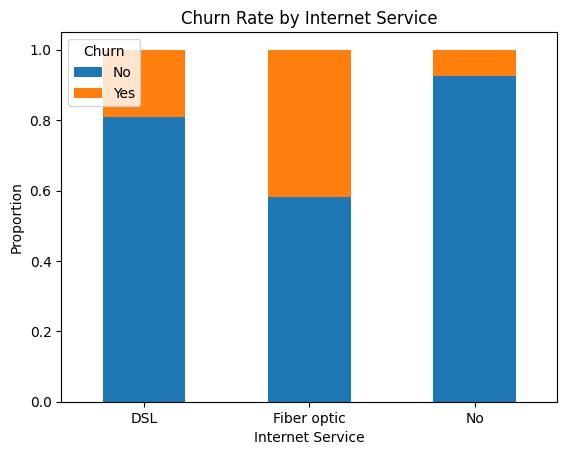

In [27]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

In [28]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [29]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


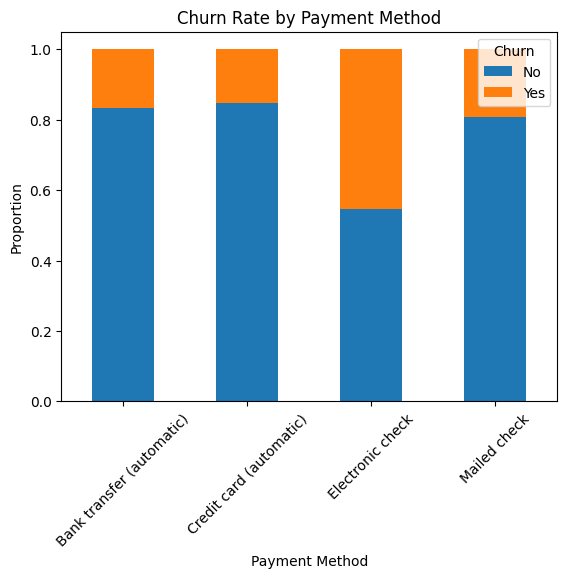

In [30]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

In [31]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [32]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


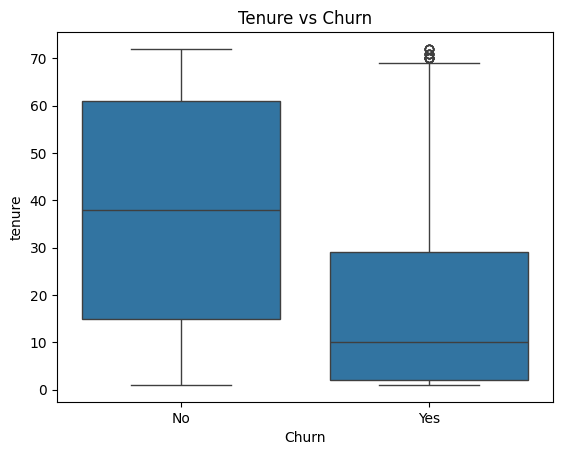

In [33]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

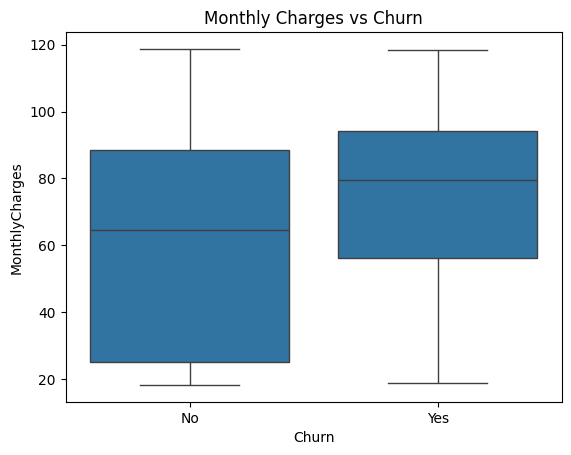

In [34]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

In [35]:
pd.crosstab(
    [df['Contract'], df['InternetService']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.520661   2.479339
Two year       DSL              98.073836   1.926164
               Fiber optic      92.773893   7.226107
               No               99.210111   0.789889

In [36]:
df.groupby(
    ['Contract', 'Churn']
)[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

tenure  MonthlyCharges  TotalCharges
Contract       Churn                                         
Month-to-month No     21.033333       61.462635   1521.927590
               Yes    14.016918       73.019396   1164.460574
One year       No     41.705972       62.540926   2903.569908
               Yes    44.963855       85.050904   4066.212048
Two year       No     56.948687       60.112798   3678.986103
               Yes    61.270833       86.777083   5432.363542

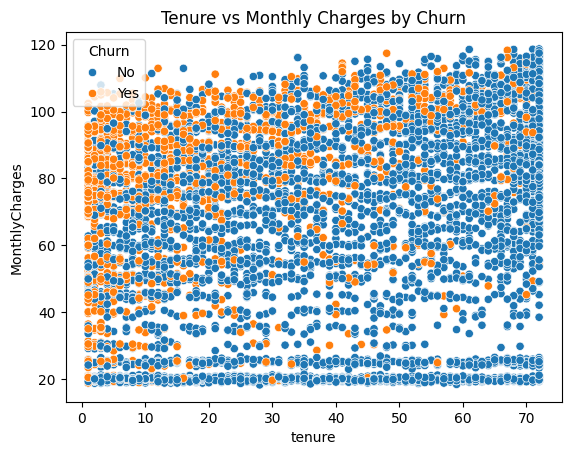

In [37]:
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title('Tenure vs Monthly Charges by Churn')
plt.show()

In [38]:
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
X_train.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

trf1 = ColumnTransformer([
    ('impute_num',
     SimpleImputer(strategy='median'),
     ['tenure', 'MonthlyCharges', 'TotalCharges']),

    ('impute_cat',
     SimpleImputer(strategy='most_frequent'),
     [
         'gender', 'Partner', 'Dependents', 'PhoneService',
         'MultipleLines', 'InternetService', 'OnlineSecurity',
         'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract',
         'PaperlessBilling', 'PaymentMethod'
     ])
], remainder='passthrough')

In [42]:
temp = trf1.fit_transform(X_train)

print(temp.shape)
print(temp[:2])

(5625, 19)
[[65.0 94.55 6078.75 'Male' 'Yes' 'Yes' 'Yes' 'Yes' 'Fiber optic' 'Yes'
  'Yes' 'Yes' 'Yes' 'No' 'No' 'Two year' 'No' 'Credit card (automatic)' 0]
 [26.0 35.75 1022.5 'Male' 'No' 'No' 'No' 'No phone service' 'DSL' 'No'
  'No' 'Yes' 'Yes' 'No' 'No' 'Month-to-month' 'No' 'Electronic check' 0]]


In [43]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
trf2 = ColumnTransformer([
    
    ('ohe',
     OneHotEncoder(
         sparse_output=False,
         handle_unknown='ignore'
     ),
     [3,4,5,6,7,8,9,10,11,12,13,14,16,17]),
    
    ('ordinal',
     OrdinalEncoder(
         categories=[['Month-to-month', 'One year', 'Two year']]
     ),
     [15])
    
], remainder='passthrough')

In [44]:
temp2 = trf2.fit_transform(temp)

print(temp2.shape)
print(temp2[:2])

(5625, 43)
[[0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0
  0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0
  0.0 0.0 2.0 65.0 94.55 6078.75 0]
 [0.0 1.0 1.0 0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0
  0.0 0.0 0.0 0.0 1.0 0.0 0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0
  1.0 0.0 0.0 26.0 35.75 1022.5 0]]


In [45]:
from sklearn.preprocessing import MinMaxScaler

trf3 = ColumnTransformer([
    ('scale',
     MinMaxScaler(),
     [39, 40, 41])
], remainder='passthrough')

In [46]:
temp3 = trf3.fit_transform(temp2)

print(temp3.shape)
print(temp3[:2])

(5625, 43)
[[0.9014084507042254 0.7596009975062343 0.6992787906762059 0.0 1.0 0.0
  1.0 0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0
  0.0 1.0 0.0 0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 2.0
  0]
 [0.35211267605633806 0.17306733167082294 0.11582044772674822 0.0 1.0 1.0
  0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0
  0.0 1.0 0.0 0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0.0
  0]]


In [47]:
from sklearn.feature_selection import SelectKBest, chi2

trf4 = SelectKBest(
    score_func=chi2,
    k=20
)

In [48]:
temp4 = trf4.fit_transform(temp3, y_train)

print(temp4.shape)

(5625, 20)


In [49]:
scores = trf4.fit(temp3, y_train)

print(scores.scores_)

[1.86992106e+02 4.08437742e+01 5.76999896e+01 9.72120638e-02
 9.64889135e-02 6.50971427e+01 6.88353473e+01 4.93735115e+01
 1.15449042e+02 4.41059873e-01 4.73184313e-02 4.24899931e+00
 4.41059873e-01 6.29333719e+00 5.64920921e+01 2.95005561e+02
 2.28447173e+02 3.36508227e+02 2.28447173e+02 1.23177070e+02
 2.33587635e+02 2.28447173e+02 2.69694565e+01 1.96233774e+02
 2.28447173e+02 1.50948212e+01 3.25647445e+02 2.28447173e+02
 1.07688602e+02 4.73957833e+01 2.28447173e+02 1.83349305e+01
 5.35941965e+01 2.28447173e+02 1.47992391e+01 1.19014017e+02
 8.08826225e+01 7.03794690e+01 7.79191602e+01 3.46643724e+02
 3.49589648e+01 9.05670078e+02 1.07464567e+02]


In [50]:
import pandas as pd

score_df = pd.DataFrame({
    'Feature_Index': range(len(scores.scores_)),
    'Chi2_Score': scores.scores_
})

score_df.sort_values(by='Chi2_Score', ascending=False).head(20)

,Feature_Index,Chi2_Score
41,41,905.670078
39,39,346.643724
17,17,336.508227
26,26,325.647445
15,15,295.005561
20,20,233.587635
21,21,228.447173
33,33,228.447173
30,30,228.447173
27,27,228.447173


In [51]:
# names produced by trf2
feature_names_trf2 = trf2.get_feature_names_out()

feature_names_trf2

array(['ohe__x3_Female', 'ohe__x3_Male', 'ohe__x4_No', 'ohe__x4_Yes',
       'ohe__x5_No', 'ohe__x5_Yes', 'ohe__x6_No', 'ohe__x6_Yes',
       'ohe__x7_No', 'ohe__x7_No phone service', 'ohe__x7_Yes',
       'ohe__x8_DSL', 'ohe__x8_Fiber optic', 'ohe__x8_No', 'ohe__x9_No',
       'ohe__x9_No internet service', 'ohe__x9_Yes', 'ohe__x10_No',
       'ohe__x10_No internet service', 'ohe__x10_Yes', 'ohe__x11_No',
       'ohe__x11_No internet service', 'ohe__x11_Yes', 'ohe__x12_No',
       'ohe__x12_No internet service', 'ohe__x12_Yes', 'ohe__x13_No',
       'ohe__x13_No internet service', 'ohe__x13_Yes', 'ohe__x14_No',
       'ohe__x14_No internet service', 'ohe__x14_Yes', 'ohe__x16_No',
       'ohe__x16_Yes', 'ohe__x17_Bank transfer (automatic)',
       'ohe__x17_Credit card (automatic)', 'ohe__x17_Electronic check',
       'ohe__x17_Mailed check', 'ordinal__x15', 'remainder__x0',
       'remainder__x1', 'remainder__x2', 'remainder__x18'], dtype=object)

In [52]:
feature_names_trf3 = trf3.get_feature_names_out(feature_names_trf2)

feature_names_trf3

array(['scale__remainder__x0', 'scale__remainder__x1',
       'scale__remainder__x2', 'remainder__ohe__x3_Female',
       'remainder__ohe__x3_Male', 'remainder__ohe__x4_No',
       'remainder__ohe__x4_Yes', 'remainder__ohe__x5_No',
       'remainder__ohe__x5_Yes', 'remainder__ohe__x6_No',
       'remainder__ohe__x6_Yes', 'remainder__ohe__x7_No',
       'remainder__ohe__x7_No phone service', 'remainder__ohe__x7_Yes',
       'remainder__ohe__x8_DSL', 'remainder__ohe__x8_Fiber optic',
       'remainder__ohe__x8_No', 'remainder__ohe__x9_No',
       'remainder__ohe__x9_No internet service', 'remainder__ohe__x9_Yes',
       'remainder__ohe__x10_No',
       'remainder__ohe__x10_No internet service',
       'remainder__ohe__x10_Yes', 'remainder__ohe__x11_No',
       'remainder__ohe__x11_No internet service',
       'remainder__ohe__x11_Yes', 'remainder__ohe__x12_No',
       'remainder__ohe__x12_No internet service',
       'remainder__ohe__x12_Yes', 'remainder__ohe__x13_No',
       'remainder_

In [53]:
score_df = pd.DataFrame({
    'Feature': feature_names_trf3,
    'Chi2_Score': scores.scores_
})

score_df.sort_values(
    by='Chi2_Score',
    ascending=False
).head(20)

,Feature,Chi2_Score
41,remainder__ordinal__x15,905.670078
39,remainder__ohe__x17_Electronic check,346.643724
17,remainder__ohe__x9_No,336.508227
26,remainder__ohe__x12_No,325.647445
15,remainder__ohe__x8_Fiber optic,295.005561
20,remainder__ohe__x10_No,233.587635
21,remainder__ohe__x10_No internet service,228.447173
33,remainder__ohe__x14_No internet service,228.447173
30,remainder__ohe__x13_No internet service,228.447173
27,remainder__ohe__x12_No internet service,228.447173


In [54]:
from sklearn.tree import DecisionTreeClassifier

trf5 = DecisionTreeClassifier(random_state=42)

In [55]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3),
    ('trf4', trf4),
    ('trf5', trf5)
])

In [56]:
pipe.fit(X_train, y_train)

,steps,"[('trf1', ...), ('trf2', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_num', ...), ('impute_cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
y_pred = pipe.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7263681592039801

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.81      0.82      0.81      1033
         Yes       0.49      0.48      0.48       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



In [60]:
confusion_matrix(y_test, y_pred)

array([[843, 190],
       [195, 179]])

In [61]:
from sklearn.linear_model import LogisticRegression

trf5_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

pipe_lr = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3),
    ('trf4', trf4),
    ('trf5', trf5_lr)
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

In [62]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [63]:
confusion_matrix(y_test, y_pred_lr)

array([[728, 305],
       [ 81, 293]])

In [66]:
from sklearn.ensemble import RandomForestClassifier

trf5_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

pipe_rf = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3),
    ('trf4', trf4),
    ('trf5', trf5_rf)
])

pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          No       0.83      0.82      0.83      1033
         Yes       0.52      0.55      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.69      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [67]:
confusion_matrix(y_test, y_pred_rf)

array([[845, 188],
       [167, 207]])

In [68]:
import pickle

with open('churn_pipeline.pkl', 'wb') as file:
    pickle.dump(pipe_lr, file)

In [69]:
import os

os.path.exists('churn_pipeline.pkl')

True